In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns',500)



#lectura de la base de datos
df=pd.read_excel("mocha-guilla-vpvs-vp-vs-x-y-z.xlsx")
df.head()

,VpVs,Vp,Vs,x,y,z
0,1.759962,5.78774,3.28856,421227.3202,7860274.252,5000
1,1.759962,5.78774,3.28856,425228.9901,7860291.168,5000
2,1.759962,5.78774,3.28856,429230.6341,7860307.202,5000
3,1.759962,5.78774,3.28856,433232.2534,7860322.354,5000
4,1.759962,5.78774,3.28856,437233.8496,7860336.625,5000


In [3]:
df = df.drop(["Vp","Vs"],axis = 1)
df = df.rename(columns = {"VpVs":"f"})
df.head()

,f,x,y,z
0,1.759962,421227.3202,7860274.252,5000
1,1.759962,425228.9901,7860291.168,5000
2,1.759962,429230.6341,7860307.202,5000
3,1.759962,433232.2534,7860322.354,5000
4,1.759962,437233.8496,7860336.625,5000


In [4]:
def slice_yz(df, x0, tol=1000):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['f']
    )
    plt.colorbar(sc, label='f')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

In [5]:
def slice_xy(df, z0, tol=1000):
    df_slice = df[np.abs(df['z'] - z0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['x'],
        df_slice['y'],
        c=df_slice['f']
    )
    plt.colorbar(sc, label='f')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Corte YZ en z ≈ {z0}')
    plt.show()

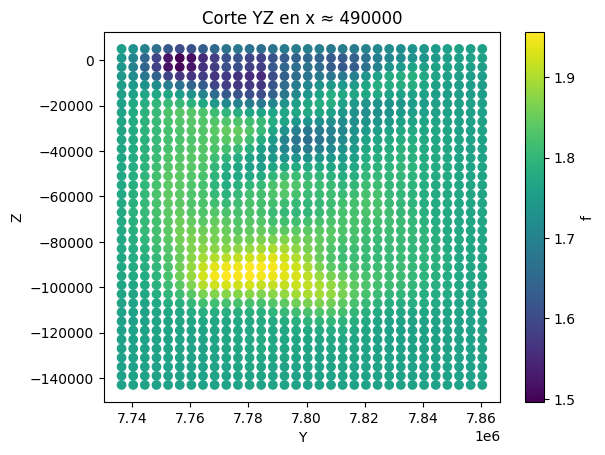

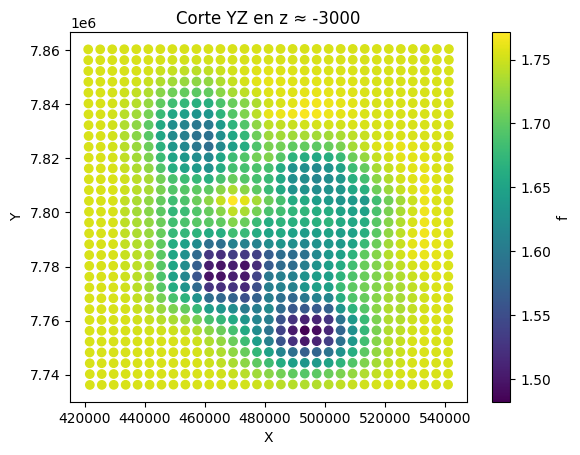

In [6]:
slice_yz(df, x0 = 490*1000)
slice_xy(df, z0 = -3*1000)

In [7]:
sizesx = df.groupby(['y','z']).size()
print(sizesx.describe())
sizesy = df.groupby(['x','z']).size()
print(sizesy.describe())
sizesz = df.groupby(['y','x']).size()
print(sizesz.describe())

count    37696.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64
count    37696.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64
count    992.0
mean      38.0
std        0.0
min       38.0
25%       38.0
50%       38.0
75%       38.0
max       38.0
dtype: float64


Funciones para derivar bien todas estas cosas y no tener que afrontar el tema del tamaño.

In [8]:
def derivada_z(grupo):
    grupo = grupo.sort_values('z')
    z = grupo['z'].values
    f = grupo['f'].values
    
    df_dz = np.gradient(f, z)
    grupo['df_dz'] = df_dz
    return grupo

def derivada_x(grupo):
    grupo = grupo.sort_values('x')
    x = grupo['x'].values
    f = grupo['f'].values
    
    df_dx = np.gradient(f, x)
    grupo['df_dx'] = df_dx
    return grupo

def derivada_y(grupo):
    grupo = grupo.sort_values('y')
    y = grupo['y'].values
    f = grupo['f'].values
    
    df_dy = np.gradient(f, y)
    grupo['df_dy'] = df_dy
    return grupo

grupo = df.groupby(['y','x'],group_keys = False).apply(derivada_z)



C:\Users\jqnra\AppData\Local\Temp\ipykernel_45856\2403124496.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupo = df.groupby(['y','x'],group_keys = False).apply(derivada_z)


In [9]:
grupo.head()

,f,x,y,z,df_dz
37665,1.761945,421780.3466,7736221.645,-143000,-3.755100e-08
36673,1.761795,421780.3466,7736221.645,-139000,-4.675987e-08
35681,1.761571,421780.3466,7736221.645,-135000,-4.965063e-08
34689,1.761398,421780.3466,7736221.645,-131000,-5.435950e-08
33697,1.761136,421780.3466,7736221.645,-127000,-6.634000e-08


Parece que no hay mucha redundancia así que la mano sería simplemente bajarle ordenes de exactitud talvez? tipo tal vez dividir por cien todo par aforzar una supuesta grilla, y jugar por ahí.

In [10]:
grupo_x = df.groupby(['y','x'],group_keys = False).apply(derivada_x)

c:\Users\jqnra\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:1305: RuntimeWarning: divide by zero encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
c:\Users\jqnra\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:1327: RuntimeWarning: divide by zero encountered in scalar divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
c:\Users\jqnra\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:1334: RuntimeWarning: divide by zero encountered in scalar divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
c:\Users\jqnra\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:1305: RuntimeWarning: divide by zero encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
c:\Users\jqnra\AppData\Local\Programs\

In [11]:
grupo_x.head()

,f,x,y,z,df_dx
0,1.759962,421227.3202,7860274.252,5000,-inf
1,1.759962,425228.9901,7860291.168,5000,-inf
2,1.759962,429230.6341,7860307.202,5000,-inf
3,1.759962,433232.2534,7860322.354,5000,-inf
4,1.759962,437233.8496,7860336.625,5000,-inf


In [12]:
df[['x','y','z']].agg(['min','max'])

,x,y,z
min,421227.3202,7736221.645,-143000
max,541271.7620,7860445.042,5000


In [13]:
df[['x','y','z']]


,x,y,z
0,421227.3202,7860274.252,5000
1,425228.9901,7860291.168,5000
2,429230.6341,7860307.202,5000
3,433232.2534,7860322.354,5000
4,437233.8496,7860336.625,5000
...,...,...,...
37691,525088.5461,7736382.277,-143000
37692,529061.9019,7736375.980,-143000
37693,533035.2676,7736368.760,-143000
37694,537008.6443,7736360.615,-143000


In [14]:
df["x_reducido"] = df[["x"]]//1000
df["y_reducido"] = df[["y"]]//1000
df["z_reducido"] = df[["z"]]//1000

In [15]:
df["x_reducido"]

0        421.0
1        425.0
2        429.0
3        433.0
4        437.0
         ...  
37691    525.0
37692    529.0
37693    533.0
37694    537.0
37695    540.0
Name: x_reducido, Length: 37696, dtype: float64

In [16]:
sizesx = df.groupby(['y_reducido','z_reducido']).size()
print(sizesx.describe())
sizesy = df.groupby(['x_reducido','z_reducido']).size()
print(sizesy.describe())
sizesz = df.groupby(['y_reducido','x_reducido']).size()
print(sizesz.describe())

count    1216.0
mean       31.0
std         0.0
min        31.0
25%        31.0
50%        31.0
75%        31.0
max        31.0
dtype: float64
count    1216.000000
mean       31.000000
std         5.222301
min         2.000000
25%        32.000000
50%        32.000000
75%        32.000000
max        32.000000
dtype: float64
count    992.0
mean      38.0
std        0.0
min       38.0
25%       38.0
50%       38.0
75%       38.0
max       38.0
dtype: float64


In [17]:
grupos_chicos = sizesy[sizesy <= 2]
print(grupos_chicos)

x_reducido  z_reducido
540.0       -143          2
            -139          2
            -135          2
            -131          2
            -127          2
            -123          2
            -119          2
            -115          2
            -111          2
            -107          2
            -103          2
            -99           2
            -95           2
            -91           2
            -87           2
            -83           2
            -79           2
            -75           2
            -71           2
            -67           2
            -63           2
            -59           2
            -55           2
            -51           2
            -47           2
            -43           2
            -39           2
            -35           2
            -31           2
            -27           2
            -23           2
            -19           2
            -15           2
            -11           2
            -7           

In [18]:
df_filtrado = df.set_index(['x_reducido','z_reducido']).loc[grupos_chicos.index]
df_filtrado

f            x            y       z  y_reducido
x_reducido z_reducido                                                        
540.0      -143        1.761945  540991.6234  7740352.967 -143000      7740.0
           -143        1.761945  540982.0335  7736351.546 -143000      7736.0
           -139        1.761795  540991.6234  7740352.967 -139000      7740.0
           -139        1.761795  540982.0335  7736351.546 -139000      7736.0
           -135        1.761571  540991.6234  7740352.967 -135000      7740.0
...                         ...          ...          ...     ...         ...
           -3          1.754362  540982.0335  7736351.546   -3000      7736.0
            1          1.757469  540991.6234  7740352.967    1000      7740.0
            1          1.757469  540982.0335  7736351.546    1000      7736.0
            5          1.759962  540991.6234  7740352.967    5000      7740.0
            5          1.759962  540982.0335  7736351.546    5000      7736.0

[76 rows x 5 columns]

In [19]:
mask = df.groupby(['x_reducido','z_reducido'])['z_reducido'].transform('size') > 31
df_limpio = df[mask]

In [20]:
df_limpio

,f,x,y,z,x_reducido,y_reducido,z_reducido
0,1.759962,421227.3202,7860274.252,5000,421.0,7860.0,5
1,1.759962,425228.9901,7860291.168,5000,425.0,7860.0,5
2,1.759962,429230.6341,7860307.202,5000,429.0,7860.0,5
3,1.759962,433232.2534,7860322.354,5000,433.0,7860.0,5
4,1.759962,437233.8496,7860336.625,5000,437.0,7860.0,5
...,...,...,...,...,...,...,...
37690,1.761945,521115.1986,7736387.649,-143000,521.0,7736.0,-143
37691,1.761945,525088.5461,7736382.277,-143000,525.0,7736.0,-143
37692,1.761945,529061.9019,7736375.980,-143000,529.0,7736.0,-143
37693,1.761945,533035.2676,7736368.760,-143000,533.0,7736.0,-143


In [21]:
df_limpio = df_limpio.drop(columns=["x", "y","z"]) \
                     .rename(columns={"x_reducido": "x",
                                      "y_reducido": "y",
                                      "z_reducido": "z"})

In [22]:
df_limpio

,f,x,y,z
0,1.759962,421.0,7860.0,5
1,1.759962,425.0,7860.0,5
2,1.759962,429.0,7860.0,5
3,1.759962,433.0,7860.0,5
4,1.759962,437.0,7860.0,5
...,...,...,...,...
37690,1.761945,521.0,7736.0,-143
37691,1.761945,525.0,7736.0,-143
37692,1.761945,529.0,7736.0,-143
37693,1.761945,533.0,7736.0,-143


In [23]:
sizesx = df_limpio.groupby(['y','z']).size()
print(sizesx.describe())
sizesy = df_limpio.groupby(['x','z']).size()
print(sizesy.describe())
sizesz = df_limpio.groupby(['y','x']).size()
print(sizesz.describe())

count    1216.0
mean       30.0
std         0.0
min        30.0
25%        30.0
50%        30.0
75%        30.0
max        30.0
dtype: float64
count    1140.0
mean       32.0
std         0.0
min        32.0
25%        32.0
50%        32.0
75%        32.0
max        32.0
dtype: float64
count    960.0
mean      38.0
std        0.0
min       38.0
25%       38.0
50%       38.0
75%       38.0
max       38.0
dtype: float64


In [24]:
grupo = df_limpio.groupby(['y','x'],group_keys = False).apply(derivada_z)
df_limpio["df_dz"] = grupo["df_dz"]
grupo = df_limpio.groupby(['y','z'],group_keys = False).apply(derivada_x)
df_limpio["df_dx"] = grupo["df_dx"]
grupo = df_limpio.groupby(['z','x'],group_keys = False).apply(derivada_y)
df_limpio["df_dy"] = grupo["df_dy"]

C:\Users\jqnra\AppData\Local\Temp\ipykernel_45856\4146767529.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupo = df_limpio.groupby(['y','x'],group_keys = False).apply(derivada_z)
C:\Users\jqnra\AppData\Local\Temp\ipykernel_45856\4146767529.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupo = df_limpio.groupby(['y','z'],group_keys = False).apply(derivada_x)
C:\Users\jqnra\AppData\Local\Temp\ipykernel_45

In [25]:
df_limpio["norm_df"] = (df_limpio["df_dz"]**2+df_limpio["df_dy"]**2+df_limpio["df_dx"]**2)

In [26]:
def slice_df_yz(df, x0, tol=10):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['norm_df']
    )
    plt.colorbar(sc, label='df_norm')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

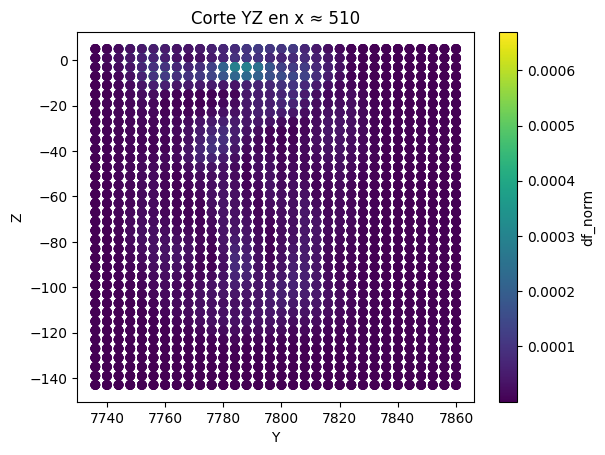

In [27]:
slice_df_yz(df_limpio, x0 = 510)


In [28]:
def slice_yz(df, x0, tol=8):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['f']
    )
    plt.colorbar(sc, label='f')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

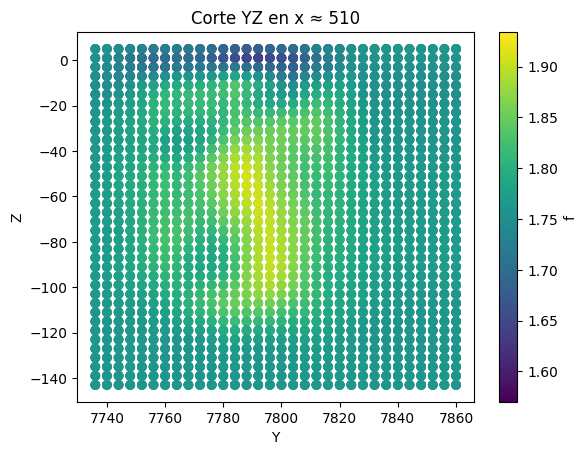

In [29]:
slice_yz(df_limpio, x0 = 510)

In [30]:
df_limpio["norm_df"].agg(["min","max"])

min    1.778414e-11
max    1.049537e-03
Name: norm_df, dtype: float64

In [31]:
df_limpio["log_norm_df"] = np.log10(df_limpio["norm_df"])
df_limpio["exp_norm_df"] = np.exp(df_limpio["norm_df"])

In [32]:
def slice_df_exp_yz(df, x0, tol=10):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['log_norm_df']
    )
    plt.colorbar(sc, label='log_norm_df')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

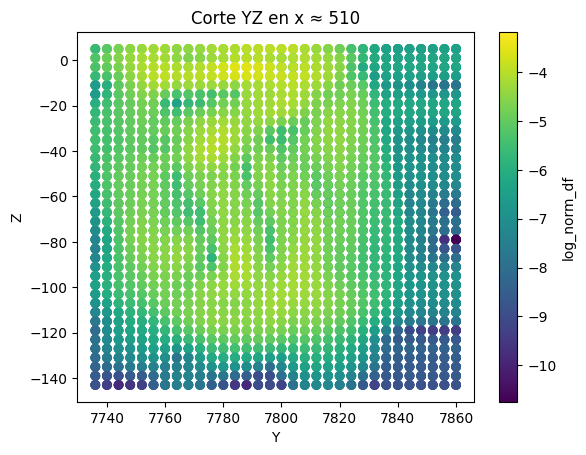

In [33]:
slice_df_exp_yz(df_limpio, x0 = 510)

In [34]:
def slice_df_e_yz(df, x0, tol=10):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['exp_norm_df']
    )
    plt.colorbar(sc, label='exp_norm_df')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

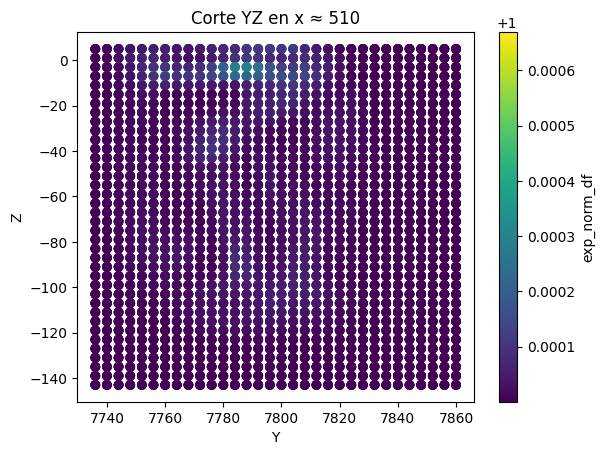

In [35]:
slice_df_e_yz(df_limpio, x0 = 510)